Name: Octavio Morales

In [199]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [200]:
def filter_image(input, filter):
    """
    Return the convolution result: image * kernel.
    Caution: use zero-padding.

    Input- image: H x W
           filter: h x w
    Output- convolve: H x W
    """
    image= np.asarray(input, dtype=np.float64)
    kernel= np.asarray(filter, dtype=np.float64)

    kh, kw= kernel.shape
    ph, pw= kh//2, kw//2

    H, W= image.shape
    padded= np.zeros((H + 2*ph, W + 2*pw), dtype=np.float64)
    padded[ph:ph+H, pw:pw+W]= image
    kernel_flipped = kernel[::-1, ::-1]

    output = np.zeros((H, W), dtype=np.float64)
    for i in range(H):
        for j in range(W):
            patch= padded[i:i+kh, j:j+kw]
            output[i, j]= np.sum(patch * kernel_flipped)
    return output


In [201]:
def sobel_operator(image):
    """
    Return Gx, Gy, and the gradient magnitude.

    Input- image: H x W
    Output- Gx, Gy, grad_magnitude: H x W
    """
    # TODO: Use filter_image() to complete the function
    tempX = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    Gx= filter_image(image, tempX)
    tempY= np.array([[-1, -2, -1], [ 0,  0, 0], [ 1,  2, 1]], dtype=np.float64)
    Gy= filter_image(image, tempY)
    grad_magnitude = np.hypot(Gx, Gy)
    return Gx, Gy, grad_magnitude

In [202]:
def generate_gaussian(sigma):
    """
    Return kernel of appropriate size
    Caution: coefficients must sum to 1

    Input- sigma: scalar (should be positive but it will be squared anyway)
    Output- kernel: W x W (no need to return W)
    """
    r= int(np.ceil(3*sigma))
    y, x= np.mgrid[-r:r+1, -r:r+1]
    kernel= np.exp(-(x*x + y*y) / (sigma*sigma*2))
    kernel= kernel / kernel.sum()
    return kernel


In [203]:
def harris_detector(image, window_size=5):
    """
    Given an input image, calculate the Harris Detector score for all pixels
    Use zero-padding to handle boundaries

    Input- image: H x W
    Output- results: a image of size H x W
    """
    # compute the derivatives
    Ix, Iy, _ = sobel_operator(image)
    Ixx, Iyy, Ixy= Ix*Ix,Iy*Iy, Ix*Iy

    # For each image location, construct the structure tensor and calculate
    # the Harris response
    w= np.ones((window_size, window_size), dtype=np.float64)/(window_size*window_size)
    Sxx= filter_image(Ixx, w)
    Syy= filter_image(Iyy, w)
    Sxy= filter_image(Ixy, w)

    k= 0.05
    det= Sxx* Syy- Sxy*Sxy
    trace= Sxx + Syy
    response = det-k* (trace ** 2)
    return response

In [204]:
def nms(input):
    """
    Non-max suppression in 3x3 windows.
    Use zero-padding.

    Input- image: H x W
    Output- nms_image: H x W
    """
    R= np.asarray(input)
    H, W= R.shape
    nms_image= np.zeros_like(R)
    Rp= np.zeros((H + 2, W + 2), dtype=R.dtype)
    Rp[1:-1, 1:-1]= R

    for i in range(H):
        for j in range(W):
            window= Rp[i:i+3, j:j+3]
            c= window[1, 1]
            w_no_center= window.copy()
            w_no_center[1, 1]= -np.inf
            keep= (c > w_no_center.max())
            nms_image[i, j]= c * keep
    return nms_image


In [205]:
def imshow(image, *args, **kwargs):
    if len(image.shape) == 3:
      # Height, width, channels
      # Assume BGR, do a conversion since
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    else:
      # Height, width - must be grayscale
      # convert to RGB, since matplotlib will plot in a weird colormap (instead of black = 0, white = 1)
      image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    # Draw the image
    plt.imshow(image, *args, **kwargs)
    # We'll also disable drawing the axes and tick marks in the plot, since it's actually an image
    plt.axis('off')
    # Make sure it outputs
    plt.show()

In [206]:
def main():
  from google.colab import drive
  drive.mount('/content/gdrive', force_remount=True)
  rootpath = '/content/gdrive/MyDrive/cs558_resources/6.869_python_tutorial/6.869_python_tutorial'
  input_image = cv2.imread(os.path.join(rootpath, "data","skyline.jpg"))
  input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)
  imshow(input_image)


  # Step 1
  print('Step 1')
  # Sobel filter
  Gx, Gy, grad_mag= sobel_operator(input_image)
  print('Absolute values of the response to the horizontal and vertical Sobel filters')
  # display
  imshow(np.abs(Gx).astype(np.uint8))
  imshow(np.abs(Gy).astype(np.uint8))

  # Step 2
  print('Step 2')
  # Gaussian filter
  sigma= 6.0
  kernel= generate_gaussian(sigma)
  print('Kernel for sigma = ' + repr(sigma))
  image_gauss= filter_image(input_image, kernel)
  k= (kernel/ (np.max(kernel) + 1e-12))*255
  imshow(k.astype(np.uint8))
  print('Image after Gaussian filtering')
  # display
  imshow(image_gauss.astype(np.uint8))

  # Step 3
  print('Step 3')
  # smooth and compute derivatives
  print('Edge gradient magnitude after Gaussian filtering')
  # display only final output - we have already seen intermediate results
  Gx_s, Gy_s, grad_mag_s= sobel_operator(image_gauss)
  imshow(grad_mag_s.astype(np.uint8))

  # Step 4
  print('Step 4')
  # Harris operator
  winsize = 5
  harris_resp = harris_detector(input_image, winsize)
  print('Magnitude of Harris operator')
  # display only final output - we have already seen intermediate results
  R_pos= np.maximum(harris_resp, 0)
  R_vis= (R_pos/(np.max(R_pos) + 1e-12))*255
  imshow(R_vis.astype(np.uint8))

  # Step 5
  print('Step 5')
  # NMS
  image_nms= nms(harris_resp)
  # Thresholding and super-imposing corners on input
  # You may implement this here or as separate function(s)
  print('Corner locations after thresholding')
  # display
  flat= image_nms.ravel()
  pos_idx= np.flatnonzero(flat > 0)
  K= min(200, pos_idx.size)
  kth= np.partition(flat[pos_idx], -K)[-K]
  mask= (image_nms >= kth).astype(np.uint8)
  imshow((mask*255).astype(np.uint8))

  print('Corners superimposed on input image')
  # display
  overlay= np.stack([input_image, input_image, input_image], axis=-1).astype(np.float64)
  ys, xs= np.nonzero(mask)
  for i in range(len(ys)):
    y= ys[i]
    x= xs[i]
    y0, y1 = max(0, y-2), min(overlay.shape[0], y+3)
    x0, x1 = max(0, x-2), min(overlay.shape[1], x+3)
    overlay[y0:y1, x0:x1, :]= [0, 255, 255]
  imshow(overlay.astype(np.uint8))


Mounted at /content/gdrive


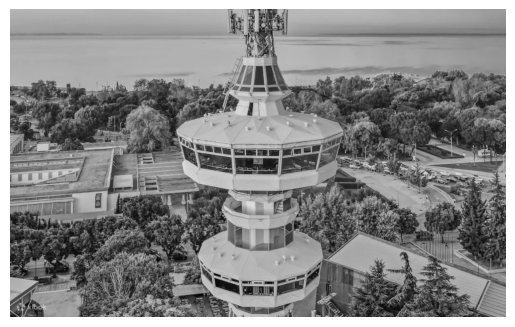

Step 1
Absolute values of the response to the horizontal and vertical Sobel filters


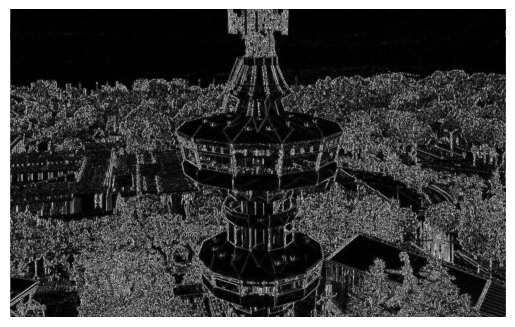

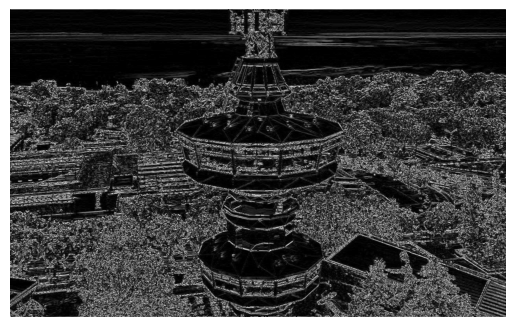

Step 2
Kernel for sigma = 6.0


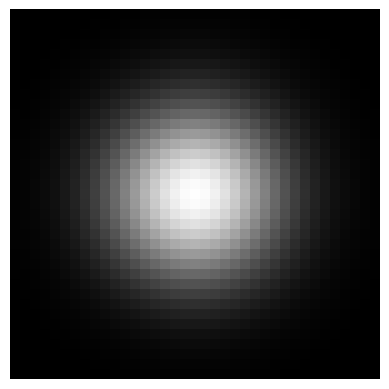

Image after Gaussian filtering


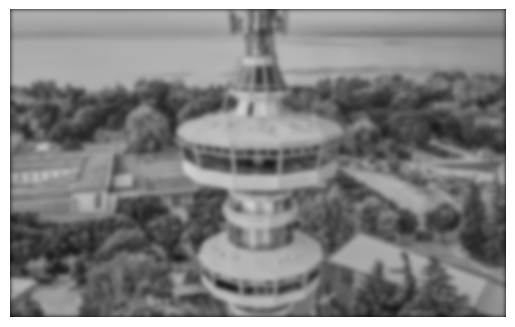

Step 3
Edge gradient magnitude after Gaussian filtering


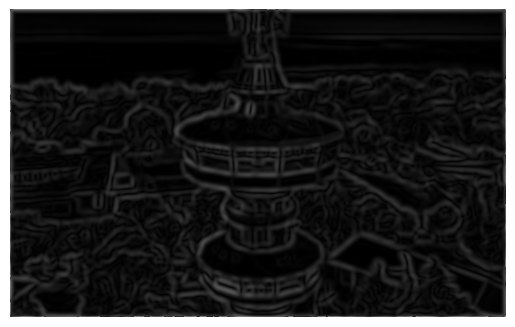

Step 4
Magnitude of Harris operator


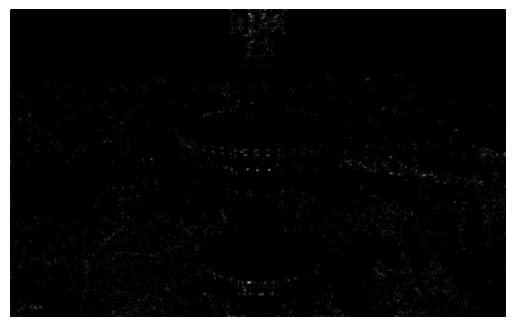

Step 5
Corner locations after thresholding


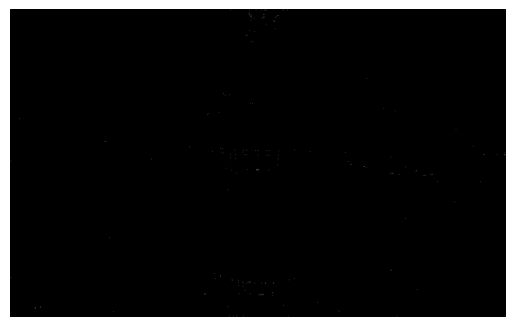

Corners superimposed on input image


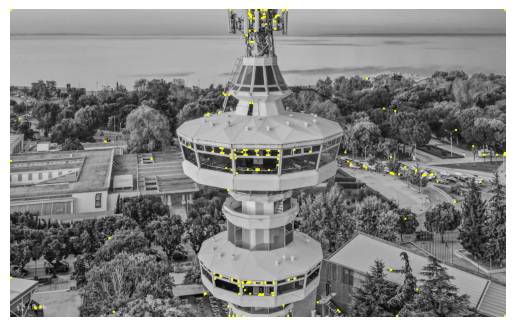

In [207]:
main()